# Task 1: Daily Return Analysis

## Objective

Calculate the daily percentage return for all mutual fund schemes using their historical NAV values.

### Formula

Daily Return = (NAVₜ / NAVₜ₋₁) − 1

## Purpose

- Measure day-to-day fund performance.
- Prepare data for advanced metrics like Sharpe Ratio, Sortino Ratio, Alpha, and Beta.
- Validate that daily returns follow a reasonable distribution.

In [3]:
# Create folder for Save all charts


import os


chart_path = r"D:\BlueStock_Fintech\Mutual_Fund_Analytics\charts"
os.makedirs(chart_path, exist_ok=True)

In [4]:
# =============================== 
# Task 1 : Daily Return Analysis
# =============================== 

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os

In [5]:
nav = pd.read_csv(
    r"D:\BlueStock_Fintech\Mutual_Fund_Analytics\data\raw\02_nav_history.csv"
)

print(nav.head())


   amfi_code        date      nav
0     119551  2022-01-03  54.3856
1     119551  2022-01-04  54.3474
2     119551  2022-01-05  54.6869
3     119551  2022-01-06  55.4550
4     119551  2022-01-07  55.3692


In [6]:
print(nav.columns)

Index(['amfi_code', 'date', 'nav'], dtype='str')


In [7]:
print(nav.info())


<class 'pandas.DataFrame'>
RangeIndex: 46000 entries, 0 to 45999
Data columns (total 3 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   amfi_code  46000 non-null  int64  
 1   date       46000 non-null  str    
 2   nav        46000 non-null  float64
dtypes: float64(1), int64(1), str(1)
memory usage: 1.1 MB
None


In [8]:
# -------------- 
# Working Copy
# -------------- 
nav_df = nav.copy()

In [9]:
nav_df["date"] = pd.to_datetime(nav_df["date"])

# Sort by Fund and Date
nav_df = nav_df.sort_values(
    by=["amfi_code", "date"]
)
nav_df

,amfi_code,date,nav
5750,100016,2022-01-03,520.4608
5751,100016,2022-01-04,515.0971
5752,100016,2022-01-05,521.7239
5753,100016,2022-01-06,515.7880
5754,100016,2022-01-07,515.1639
...,...,...,...
45995,149324,2026-05-25,292.4810
45996,149324,2026-05-26,291.2707
45997,149324,2026-05-27,288.8007
45998,149324,2026-05-28,280.6873


In [10]:
# -------------------- 
# Compute Daily Return
# --------------------

nav_df["daily_return"] = (
    nav_df
    .groupby("amfi_code")["nav"]
    .pct_change()
)

# Remove first NaN return for every fund
daily_returns_df = nav_df.dropna(
    subset=["daily_return"]
).copy()


In [11]:
# --------------- 
# Display Sample
# ---------------

print("="*60)
print("Daily Return Sample")
print("="*60)

print(
    daily_returns_df[
        ["amfi_code", "date", "nav", "daily_return"]
    ].head(10)
)

Daily Return Sample
      amfi_code       date       nav  daily_return
5751     100016 2022-01-04  515.0971     -0.010306
5752     100016 2022-01-05  521.7239      0.012865
5753     100016 2022-01-06  515.7880     -0.011377
5754     100016 2022-01-07  515.1639     -0.001210
5755     100016 2022-01-10  510.7136     -0.008639
5756     100016 2022-01-11  513.5542      0.005562
5757     100016 2022-01-12  512.3195     -0.002404
5758     100016 2022-01-13  510.2445     -0.004050
5759     100016 2022-01-14  514.3636      0.008073
5760     100016 2022-01-17  514.7627      0.000776


In [12]:
# ------------------------ 
# Distribution Statistics
# ------------------------ 

print("\nSummary Statistics\n")

print(
    daily_returns_df["daily_return"].describe()
)


Summary Statistics

count    45960.000000
mean         0.000631
std          0.010290
min         -0.058102
25%         -0.005042
50%          0.000340
75%          0.006324
max          0.064713
Name: daily_return, dtype: float64


In [13]:
# ----------------------------------------------------------
# Save CSV
# ----------------------------------------------------------

processed_path = r"D:\BlueStock_Fintech\Mutual_Fund_Analytics\data\processed"

daily_returns_df.to_csv(
    os.path.join(
        processed_path,
        "daily_returns.csv"
    ),
    index=False
)

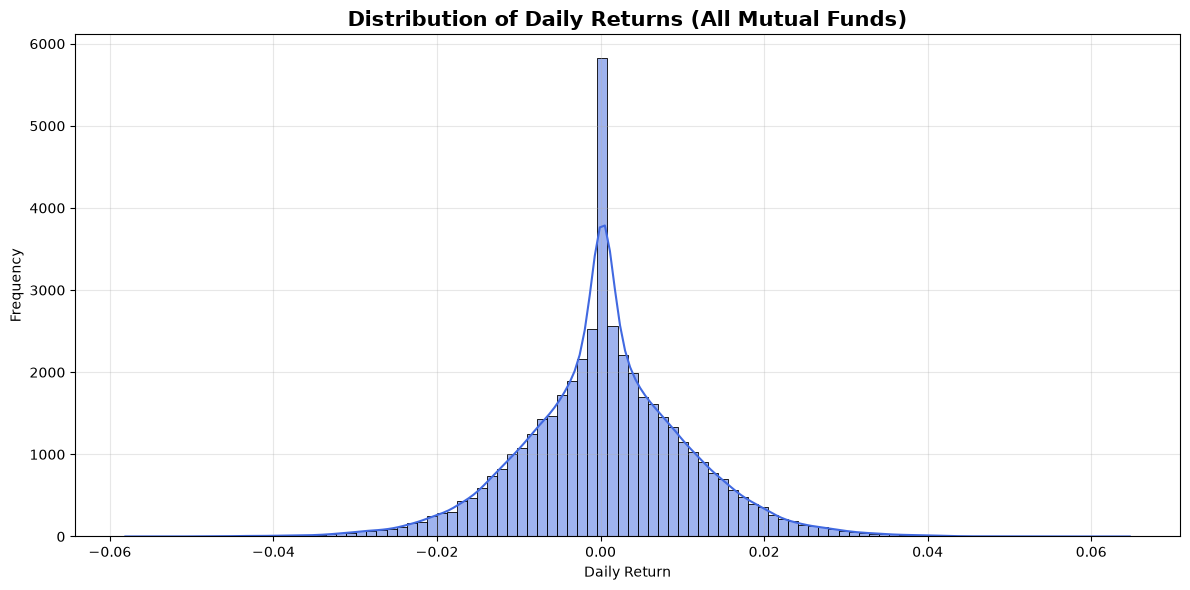

In [14]:
# ----------------------------------------------------------
# Histogram
# ----------------------------------------------------------

plt.figure(figsize=(12,6))

sns.histplot(
    daily_returns_df["daily_return"],
    bins=100,
    kde=True,
    color="royalblue"
)

plt.title(
    "Distribution of Daily Returns (All Mutual Funds)",
    fontsize=15,
    fontweight="bold"
)

plt.xlabel("Daily Return")

plt.ylabel("Frequency")

plt.grid(alpha=0.3)

plt.tight_layout()

plt.savefig(
    os.path.join(
        chart_path,
        "task4_daily_return_distribution.png"
    ),
    dpi=300,
    bbox_inches="tight"
)

plt.show()


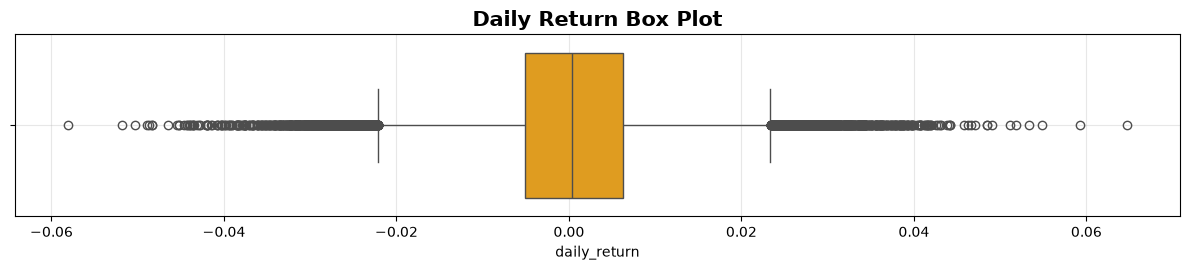


Top 10 Highest Daily Returns

       amfi_code       date  daily_return
2895      119598 2024-04-15      0.064713
20126     118634 2024-03-19      0.059304
33957     101207 2024-05-01      0.054851
3716      119599 2023-01-10      0.053320
3982      119599 2024-01-17      0.051811
2305      119598 2022-01-10      0.051113
2521      119598 2022-11-08      0.049051
45082     149324 2022-11-23      0.048490
2506      119598 2022-10-18      0.048454
3241      119598 2025-08-12      0.047123

Top 10 Lowest Daily Returns

       amfi_code       date  daily_return
19674     118634 2022-06-24     -0.058102
33667     101207 2023-03-22     -0.051847
19852     118634 2023-03-01     -0.050335
45312     149324 2023-10-11     -0.048870
34310     101207 2025-09-08     -0.048634
31304     119095 2022-12-23     -0.048367
20233     118634 2024-08-15     -0.048305
31807     119095 2024-11-27     -0.046524
4198      119599 2024-11-14     -0.045429
9770      125498 2024-03-11     -0.045218

Task 1 Complet

In [15]:

# ----------- 
# Box Plot
# -----------

plt.figure(figsize=(12,2.8))

sns.boxplot(
    x=daily_returns_df["daily_return"],
    color="orange"
)

plt.title(
    "Daily Return Box Plot",
    fontsize=15,
    fontweight="bold"
)

plt.grid(alpha=0.3)

plt.tight_layout()

plt.savefig(
    os.path.join(
        chart_path,
        "task1_daily_return_boxplot.png"
    ),
    dpi=300,
    bbox_inches="tight"
)
plt.savefig(
    os.path.join(
        chart_path,
        "task4_boxPlt.png"
    ),
    dpi=300,
    bbox_inches="tight"
)

plt.show()

# ----------------------------------------------------------
# Top Positive Returns
# ----------------------------------------------------------

top_positive = (
    daily_returns_df
    .nlargest(10, "daily_return")
)

print("\nTop 10 Highest Daily Returns\n")

print(
    top_positive[
        ["amfi_code", "date", "daily_return"]
    ]
)

# ----------------------------------------------------------
# Top Negative Returns
# ----------------------------------------------------------

top_negative = (
    daily_returns_df
    .nsmallest(10, "daily_return")
)

print("\nTop 10 Lowest Daily Returns\n")

print(
    top_negative[
        ["amfi_code", "date", "daily_return"]
    ]
)



print("\nTask 1 Completed Successfully!")

# Task 2: Compound Annual Growth Rate (CAGR)

# Objective

Calculate the Compound Annual Growth Rate (CAGR) for each mutual fund over 1-year, 3-year, and 5-year investment periods.

# Formula

CAGR = (NAV_end / NAV_start)^(1/n) - 1

# Purpose

- Compare long-term performance across mutual funds.
- Remove the effect of investment duration.
- Identify consistently high-performing schemes.

In [16]:
# ------------- 
# Working Copy
# ------------- 

cagr_df = nav.copy()

cagr_df["date"] = pd.to_datetime(cagr_df["date"])

cagr_df = cagr_df.sort_values(
    ["amfi_code", "date"]
)


In [17]:
# ----------------------------------------------------------
# Load Fund Names
# ----------------------------------------------------------

fund_master = pd.read_csv(
    r"D:\BlueStock_Fintech\Mutual_Fund_Analytics\data\raw\01_fund_master.csv"
)

fund_names = fund_master[
    ["amfi_code", "scheme_name"]
]


In [18]:
# ----------------------------------------------------------
# Function to Calculate CAGR
# ----------------------------------------------------------

def calculate_cagr(group, years):

    end_date = group["date"].max()

    start_date = end_date - pd.DateOffset(years=years)

    period = group[group["date"] >= start_date]

    if len(period) < 2:
        return np.nan

    start_nav = period.iloc[0]["nav"]

    end_nav = period.iloc[-1]["nav"]

    cagr = ((end_nav / start_nav) ** (1 / years)) - 1

    return cagr


# --------------- 
# Calculate CAGR
# --------------- 

results = []

for amfi, group in cagr_df.groupby("amfi_code"):

    one = calculate_cagr(group, 1)
    three = calculate_cagr(group, 3)
    five = calculate_cagr(group, 5)

    results.append([
        amfi,
        one,
        three,
        five
    ])

cagr_table = pd.DataFrame(
    results,
    columns=[
        "amfi_code",
        "CAGR_1Y",
        "CAGR_3Y",
        "CAGR_5Y"
    ]
)

In [19]:
cagr_table = cagr_table.merge(
    fund_names,
    on="amfi_code",
    how="left"
)

for col in ["CAGR_1Y", "CAGR_3Y", "CAGR_5Y"]:

    cagr_table[col] *= 100


# --------------------- 
# Sort by 3-Year CAGR
# --------------------- 
cagr_table = cagr_table.sort_values(
    "CAGR_3Y",
    ascending=False
)

In [20]:
top10 = cagr_table.head(10)
top10

,amfi_code,CAGR_1Y,CAGR_3Y,CAGR_5Y,scheme_name
16,119094,22.261065,35.111802,24.445309,Axis Midcap Fund - Regular - Growth
34,148567,20.360678,34.000916,26.799277,Mirae Asset Large Cap Fund - Regular - Growth
24,120504,13.064279,32.487429,20.234028,ICICI Pru Bluechip Fund - Direct - Growth
2,100033,53.232396,32.442459,26.074068,HDFC Mid-Cap Opportunities Fund - Regular - Gr...
25,120505,29.604659,31.777537,28.376762,ICICI Pru Midcap Fund - Regular - Growth
19,119551,60.437341,30.456524,22.384873,SBI Bluechip Fund - Regular Plan - Growth
30,120843,26.657082,29.582770,26.742494,Kotak Flexicap Fund - Regular - Growth
36,148569,39.751761,29.178902,27.629860,Mirae Asset Tax Saver Fund - Regular - Growth
3,101206,47.924120,28.967695,20.442730,ABSL Frontline Equity Fund - Regular - Growth
39,149324,65.138719,27.000427,27.917430,DSP Small Cap Fund - Regular - Growth


In [21]:
# ----------------------------------------------------------
# Save CSV
# ----------------------------------------------------------

processed_path = r"D:\BlueStock_Fintech\Mutual_Fund_Analytics\data\processed"

cagr_table.to_csv(
    os.path.join(
        processed_path,
        "cagr_comparison.csv"
    ),
    index=False
)

Chart  : Top 10 Funds by 3-Year CAGR

C:\Users\vishesh\AppData\Local\Temp\ipykernel_14068\2921640402.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


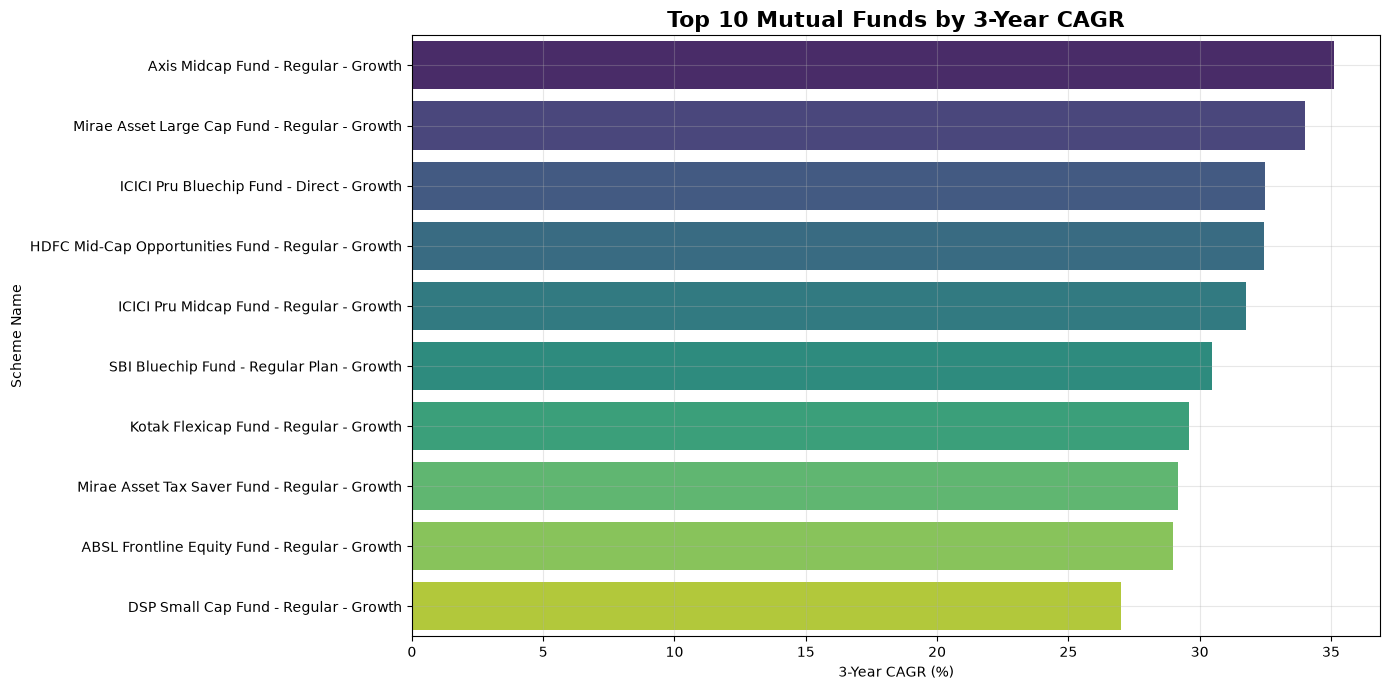

In [22]:
plt.figure(figsize=(14,7))

sns.barplot(
    data=top10,
    x="CAGR_3Y",
    y="scheme_name",
    palette="viridis"
)

plt.title(
    "Top 10 Mutual Funds by 3-Year CAGR",
    fontsize=16,
    fontweight="bold"
)

plt.xlabel("3-Year CAGR (%)")

plt.ylabel("Scheme Name")

plt.grid(alpha=0.3)

 
plt.tight_layout()

plt.savefig(
    os.path.join(
        chart_path,
        "task4_top10_cagr.png"
    ),
    dpi=300,
    bbox_inches="tight"
)

plt.show()


CAGR Comparison

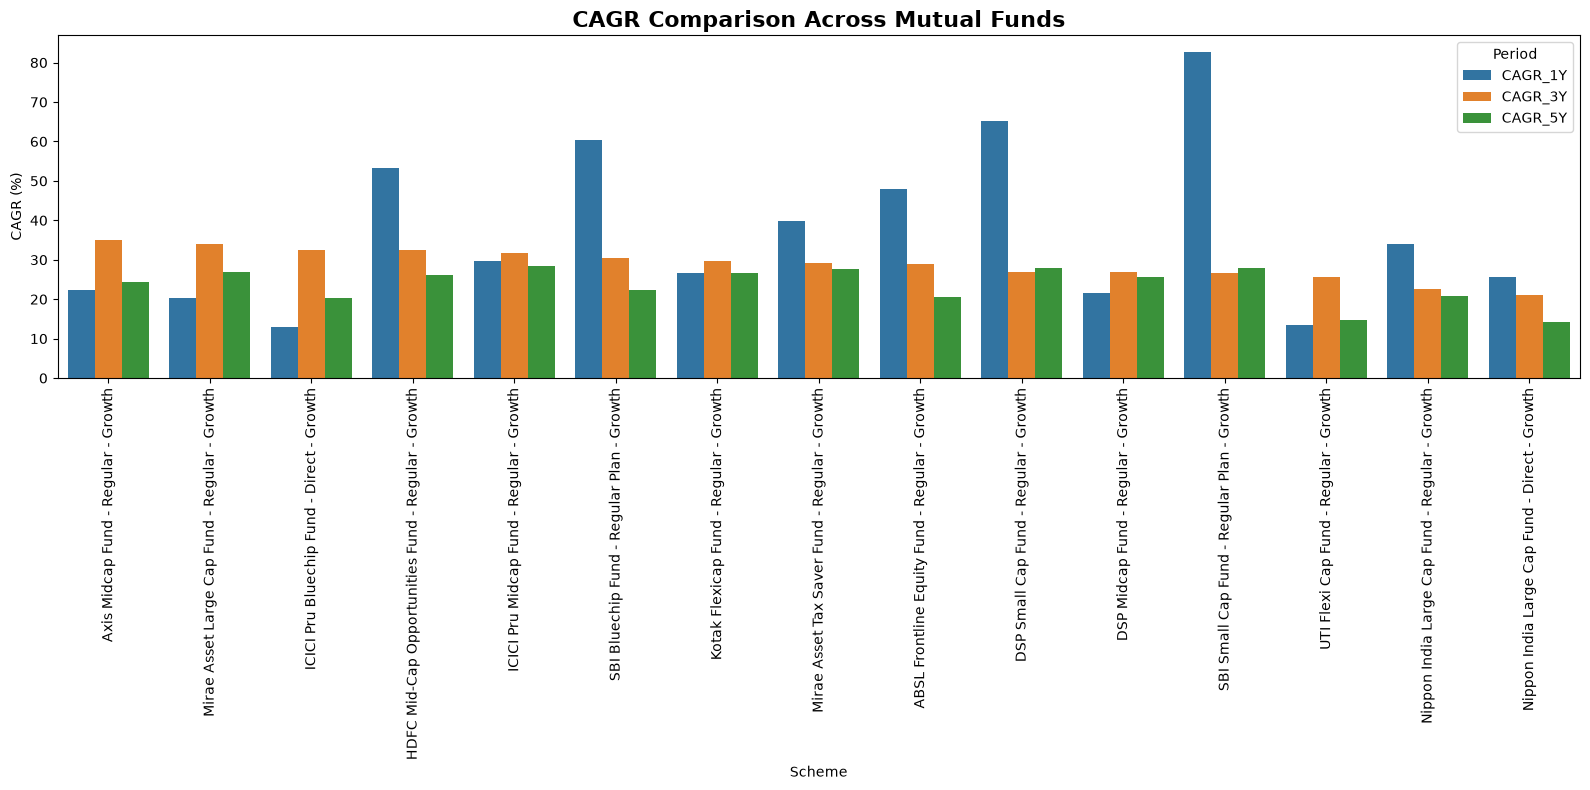


Task 2 Completed Successfully!


In [23]:

plot_df = cagr_table.head(15).copy()

plot_df = plot_df.melt(
    id_vars="scheme_name",
    value_vars=[
        "CAGR_1Y",
        "CAGR_3Y",
        "CAGR_5Y"
    ],
    var_name="Period",
    value_name="CAGR"
)

plt.figure(figsize=(16,8))

sns.barplot(
    data=plot_df,
    x="scheme_name",
    y="CAGR",
    hue="Period"
)

plt.xticks(
    rotation=90
)

plt.title(
    "CAGR Comparison Across Mutual Funds",
    fontsize=16,
    fontweight="bold"
)

plt.xlabel("Scheme")

plt.ylabel("CAGR (%)")

plt.tight_layout()

plt.savefig(
    os.path.join(
        chart_path,
        "task4_cagr_comparison.png"
    ),
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print("\nTask 2 Completed Successfully!")

# Task 3: Sharpe Ratio Analysis

# Objective

Evaluate the risk-adjusted performance of each mutual fund using the Sharpe Ratio.

# Formula

Sharpe Ratio = ((Rp - Rf) / σ) × √252

Where:

- Rp = Average Daily Return
- Rf = Risk-Free Rate (6.5%)
- σ = Standard Deviation of Daily Returns

## Purpose

- Measure return generated per unit of risk.
- Compare funds with different volatility levels.
- Rank funds based on risk-adjusted performance.

In [24]:
# --------------
# Working Copy
# -------------- 

returns_df = daily_returns_df.copy()

In [25]:
risk_free_rate = 0.065

daily_rf = risk_free_rate / 252

In [26]:
# ----------------------------------------------------------
# Calculate Sharpe Ratio
# ----------------------------------------------------------

sharpe = (
    returns_df
    .groupby("amfi_code")
    .agg(
        Mean_Return=("daily_return","mean"),
        Std_Return=("daily_return","std")
    )
    .reset_index()
)

sharpe["Sharpe_Ratio"] = (
    (sharpe["Mean_Return"] - daily_rf)
    /
    sharpe["Std_Return"]
) * np.sqrt(252)

 

In [27]:
sharpe.shape  # contain  Rank all 40 funds.

(40, 4)

In [28]:
sharpe.sample(10)

,amfi_code,Mean_Return,Std_Return,Sharpe_Ratio
33,125498,0.000477,0.011561,0.300612
27,120507,0.000268,0.000311,0.495723
6,102885,0.000674,0.008086,0.817099
12,118635,0.000600,0.008179,0.664857
10,118633,0.000616,0.008817,0.645207
0,100016,0.000142,0.009164,-0.201517
35,148568,0.000825,0.009719,0.926287
7,102886,0.000110,0.011424,-0.205832
30,120843,0.001082,0.010008,1.306744
23,120503,0.000698,0.008746,0.797973


In [29]:
sharpe = sharpe.merge(
    fund_master[["amfi_code","scheme_name"]],
    on="amfi_code",
    how="left"
)

 Ranking


In [30]:
sharpe = sharpe.sort_values(
    "Sharpe_Ratio",
    ascending=False
)

sharpe["Rank"] = range(1,len(sharpe)+1)


 Save CSV

In [31]:
sharpe.to_csv(
    os.path.join(
        processed_path,
        "sharpe_ratio.csv"
    ),
    index=False
)

# Visualization

C:\Users\vishesh\AppData\Local\Temp\ipykernel_14068\4193645183.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


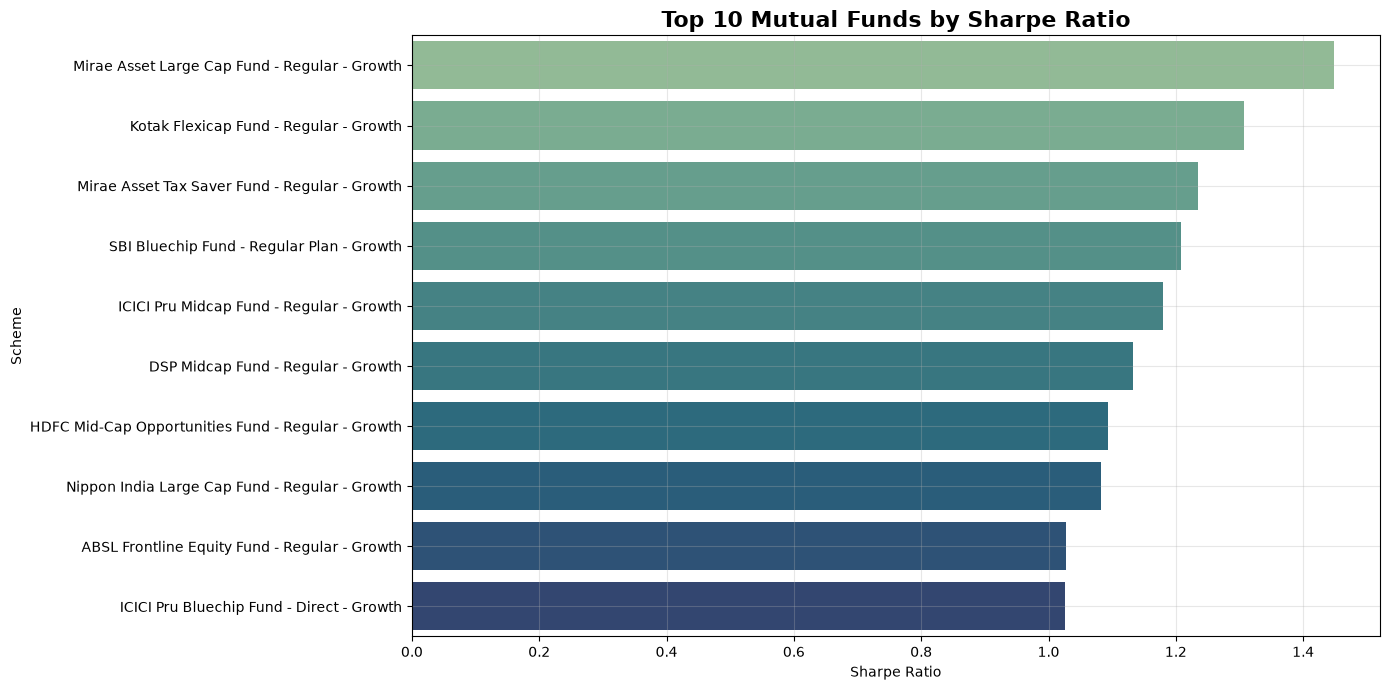

Task 3 Completed Successfully!


In [32]:
top10 = sharpe.head(10)

plt.figure(figsize=(14,7))

sns.barplot(
    data=top10,
    x="Sharpe_Ratio",
    y="scheme_name",
    palette="crest"
)

plt.title(
    "Top 10 Mutual Funds by Sharpe Ratio",
    fontsize=16,
    fontweight="bold"
)

plt.xlabel("Sharpe Ratio")

plt.ylabel("Scheme")

plt.grid(alpha=0.3)

plt.tight_layout()

plt.savefig(
    os.path.join(
        chart_path,
        "task4_sharpe_ratio.png"
    ),
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print("Task 3 Completed Successfully!")

# Task 4: Sortino Ratio Analysis

## Objective

Evaluate mutual funds using downside risk instead of total volatility.

### Formula

Sortino Ratio = ((Rp - Rf) / Downside Std Dev) × √252

Where:

- Rp = Average Daily Return
- Rf = Daily Risk-Free Rate
- Downside Std Dev = Standard deviation of negative daily returns

## Purpose

- Measure downside risk-adjusted performance.
- Ignore positive volatility.
- Identify funds that minimize losses while generating returns.

In [33]:
# ----------------------------------------------------------
# Working Copy
# ----------------------------------------------------------

sortino_df = daily_returns_df.copy()

In [34]:
risk_free_rate = 0.065
daily_rf = risk_free_rate / 252


Function to Calculate Sortino Ratio

In [35]:
def calculate_sortino(group):

    mean_return = group["daily_return"].mean()

    downside_returns = group.loc[
        group["daily_return"] < 0,
        "daily_return"
    ]

    downside_std = downside_returns.std()

    if downside_std == 0 or np.isnan(downside_std):
        return np.nan

    sortino = (
        (mean_return - daily_rf)
        /
        downside_std
    ) * np.sqrt(252)

    return sortino


 Calculate Sortino Ratio

In [36]:
sortino = (
    sortino_df
    .groupby("amfi_code")
    .apply(calculate_sortino)
    .reset_index(name="Sortino_Ratio")
)

In [37]:
sorti_no = sortino.merge(
    fund_master[
        ["amfi_code", "scheme_name"]
    ],
    on="amfi_code",
    how="left"
)
sorti_no.sample(10)

,amfi_code,Sortino_Ratio,scheme_name
19,119551,2.140267,SBI Bluechip Fund - Regular Plan - Growth
38,149323,1.875101,DSP Midcap Fund - Regular - Growth
3,101206,1.799563,ABSL Frontline Equity Fund - Regular - Growth
17,119095,-0.128186,Axis Small Cap Fund - Regular - Growth
14,119092,0.052574,Axis Bluechip Fund - Regular - Growth
27,120507,1.052124,ICICI Pru Liquid Fund - Regular - Growth
37,149322,0.762129,DSP Top 100 Equity Fund - Regular - Growth
1,100025,-0.941821,HDFC Short Term Debt Fund - Regular - Growth
9,118632,1.850133,Nippon India Large Cap Fund - Regular - Growth
18,119120,-0.376767,SBI Magnum Gilt Fund - Regular Plan - Growth


In [38]:
sortino_rank = sorti_no.sort_values(
    "Sortino_Ratio",
    ascending=False
)

sortino_rank["Rank"] = range(
    1,
    len(sortino_rank)+1
)


 Save CSV

In [39]:
sorti_no.to_csv(
    os.path.join(
        processed_path,
        "sorti_no_ratio.csv"
    ),
    index=False
)

 Visualization

C:\Users\vishesh\AppData\Local\Temp\ipykernel_14068\4059214693.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


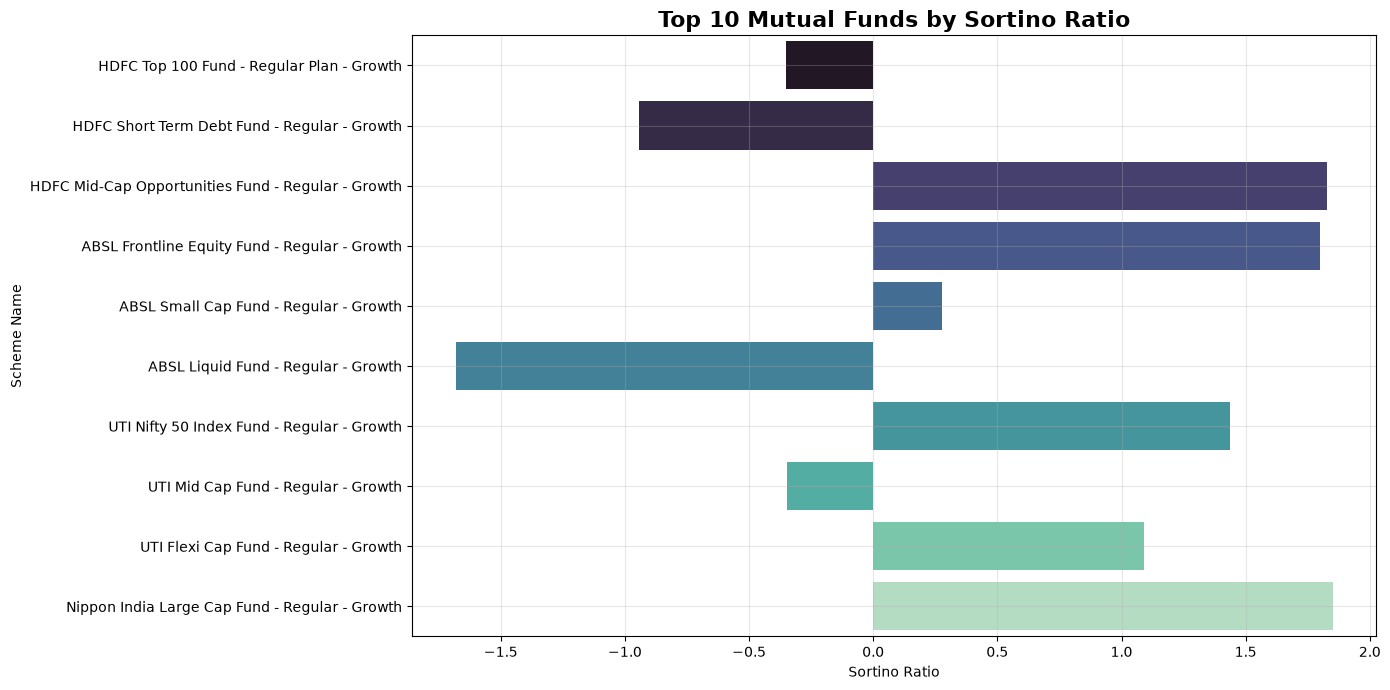

Task 4 Completed Successfully!


In [40]:
top10 = sorti_no.head(10)

plt.figure(figsize=(14,7))

sns.barplot(
    data=top10,
    x="Sortino_Ratio",
    y="scheme_name",
    palette="mako"
)

plt.title(
    "Top 10 Mutual Funds by Sortino Ratio",
    fontsize=16,
    fontweight="bold"
)

plt.xlabel("Sortino Ratio")

plt.ylabel("Scheme Name")

plt.grid(alpha=0.3)

plt.tight_layout()

plt.savefig(
    os.path.join(
        chart_path,
        "task4_sortino_ratio.png"
    ),
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print("Task 4 Completed Successfully!")


# Task 5: Alpha & Beta Analysis

## Objective

Calculate Alpha and Beta for each mutual fund using NIFTY100 as the benchmark through linear regression.

### Formula

Fund Return = Alpha + Beta × Benchmark Return

Annualized Alpha = Intercept × 252

## Purpose

- Evaluate fund manager's ability to outperform the benchmark.
- Measure market sensitivity.
- Compare fund performance against NIFTY100.

In [41]:
from scipy.stats import linregress


benchmark = pd.read_csv(
    r"D:\BlueStock_Fintech\Mutual_Fund_Analytics\data\raw\10_benchmark_indices.csv"
)

print(benchmark.head())
 

         date index_name  close_value
0  2022-01-03    NIFTY50     17492.79
1  2022-01-04    NIFTY50     17689.64
2  2022-01-05    NIFTY50     17835.05
3  2022-01-06    NIFTY50     17878.51
4  2022-01-07    NIFTY50     17759.15


 Working Copies

In [42]:
benchmark_df = benchmark.copy()

 Filter NIFTY100

In [43]:
nifty100 = benchmark_df[
    benchmark_df["index_name"] == "NIFTY100"
].copy()

nifty100 = nifty100.sort_values("date")

 Calculate Benchmark Daily Returns

In [44]:
nifty100["benchmark_return"] = nifty100["close_value"].pct_change()

nifty100 = nifty100.dropna()

 Daily Returns Dataset

In [45]:
fund_returns = daily_returns_df.copy()

fund_returns["date"] = pd.to_datetime(fund_returns["date"])
nifty100["date"] = pd.to_datetime(nifty100["date"])


Merge Fund Returns with Benchmark Returns

In [46]:
merged = pd.merge(
    fund_returns,
    nifty100[
        ["date", "benchmark_return"]
    ],
    on="date",
    how="inner"
)

 Calculate Alpha & Beta

In [47]:
results = []

for amfi, group in merged.groupby("amfi_code"):

    if len(group) < 30:
        continue

    regression = linregress(
        group["benchmark_return"],
        group["daily_return"]
    )

    beta = regression.slope

    alpha = regression.intercept * 252

    r_squared = regression.rvalue ** 2

    results.append([
        amfi,
        alpha,
        beta,
        r_squared
    ])

alpha_beta = pd.DataFrame(
    results,
    columns=[
        "amfi_code",
        "Alpha",
        "Beta",
        "R_Squared"
    ]
)

Merge Fund Name

In [48]:
alpha_beta = alpha_beta.merge(
    fund_master[
        ["amfi_code", "scheme_name"]
    ],
    on="amfi_code",
    how="left"
)

# Ranking


alpha_beta = alpha_beta.sort_values(
    "Alpha",
    ascending=False
)

alpha_beta["Rank"] = range(
    1,
    len(alpha_beta)+1
)


In [49]:
alpha_beta.head(5)

,amfi_code,Alpha,Beta,R_Squared,scheme_name,Rank
21,119598,0.303370,-0.023196,1.414258e-04,SBI Small Cap Fund - Regular Plan - Growth,1
39,149324,0.300579,0.011455,3.532991e-05,DSP Small Cap Fund - Regular - Growth,2
25,120505,0.292636,0.000549,1.345534e-07,ICICI Pru Midcap Fund - Regular - Growth,3
36,148569,0.282704,0.018134,1.748889e-04,Mirae Asset Tax Saver Fund - Regular - Growth,4
30,120843,0.273305,-0.022830,3.430543e-04,Kotak Flexicap Fund - Regular - Growth,5


In [50]:
# ----------- 
# Save CSV
# ----------- 
alpha_beta.to_csv(
    os.path.join(
        processed_path,
        "alpha_beta.csv"
    ),
    index=False
)

 

Visualization for better understanding

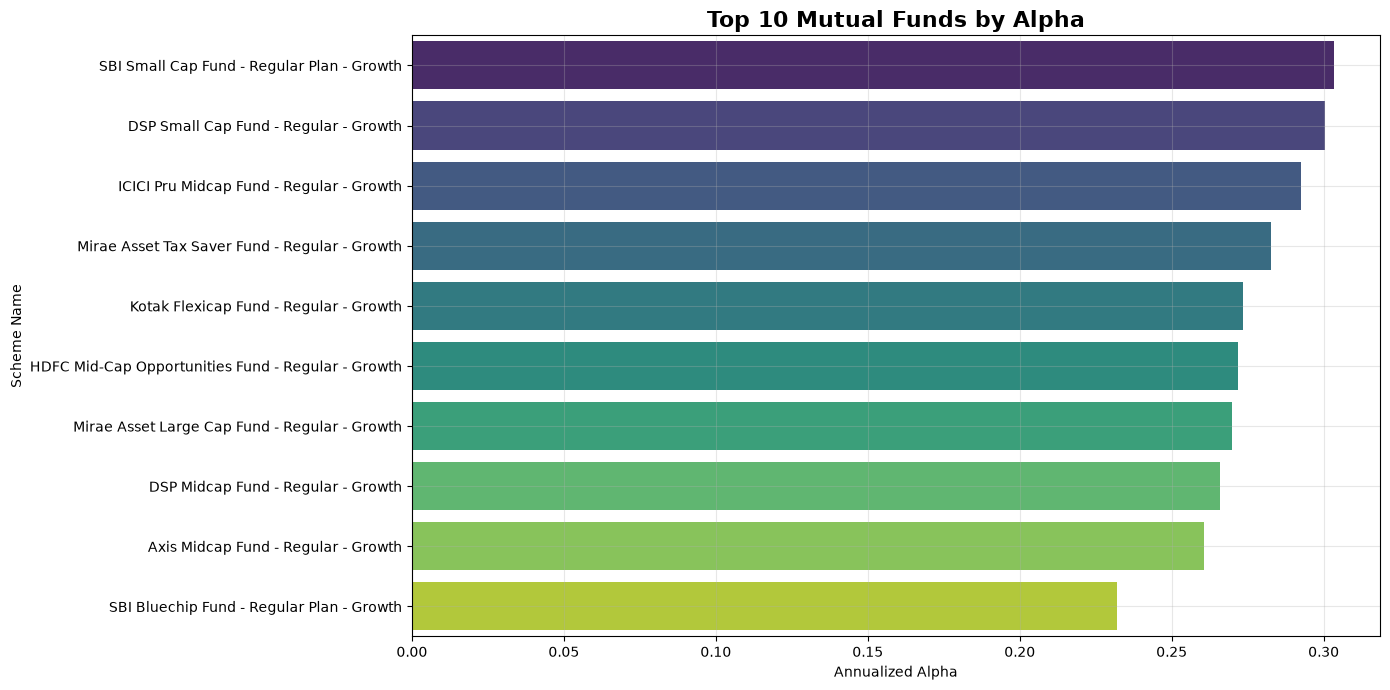

In [51]:
top10 = alpha_beta.head(10)

plt.figure(figsize=(14,7))

sns.barplot(
    data=top10,
    x="Alpha",
    y="scheme_name",
    hue="scheme_name",
    palette="viridis",
    legend=False
)

plt.title(
    "Top 10 Mutual Funds by Alpha",
    fontsize=16,
    fontweight="bold"
)

plt.xlabel("Annualized Alpha")

plt.ylabel("Scheme Name")

plt.grid(alpha=0.3)

plt.tight_layout()

plt.savefig(
    os.path.join(
        chart_path,
        "task5_alpha.png"
    ),
    dpi=300
)

plt.show()

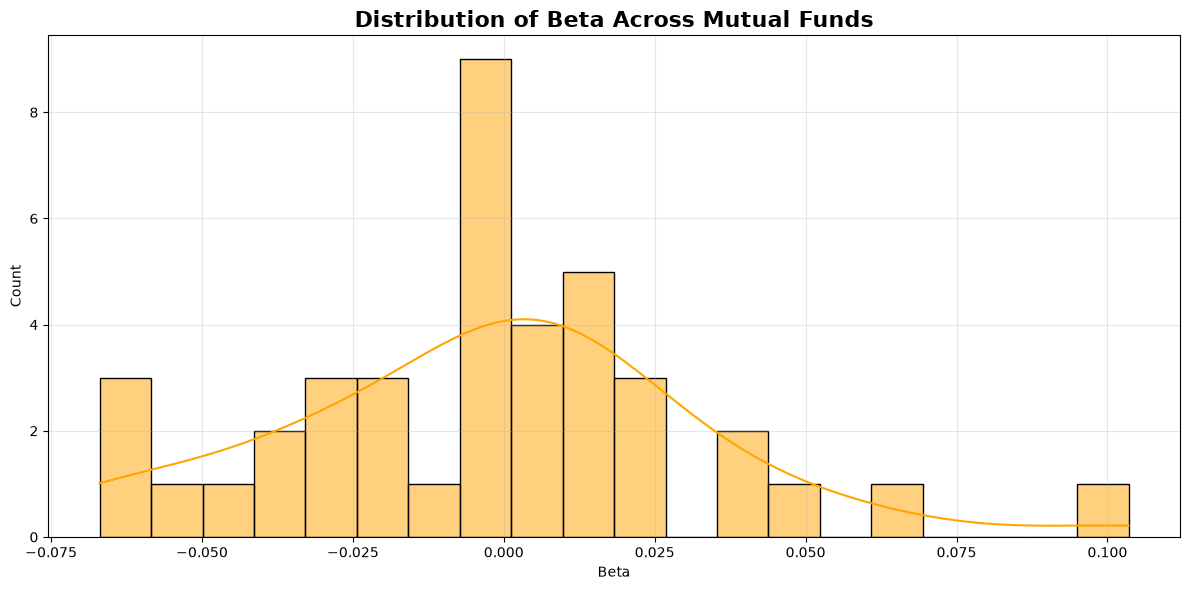

In [52]:
plt.figure(figsize=(12,6))

sns.histplot(
    alpha_beta["Beta"],
    bins=20,
    kde=True,
    color="orange"
)

plt.title(
    "Distribution of Beta Across Mutual Funds",
    fontsize=16,
    fontweight="bold"
)

plt.xlabel("Beta")

plt.grid(alpha=0.3)

plt.tight_layout()

plt.savefig(
    os.path.join(
        chart_path,
        "task5_beta_distribution.png"
    ),
    dpi=300
)

plt.show()

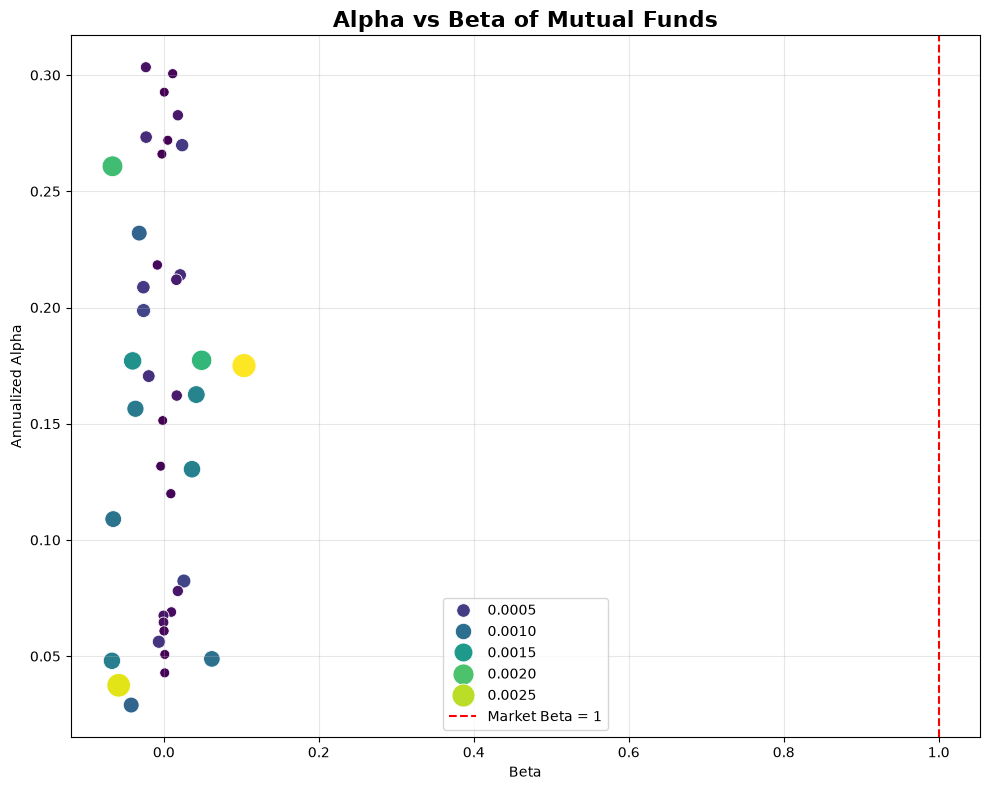

In [53]:
plt.figure(figsize=(10,8))

sns.scatterplot(
    data=alpha_beta,
    x="Beta",
    y="Alpha",
    size="R_Squared",
    hue="R_Squared",
    palette="viridis",
    sizes=(50,300)
)

plt.axvline(1, color="red", linestyle="--", label="Market Beta = 1")

plt.title(
    "Alpha vs Beta of Mutual Funds",
    fontsize=16,
    fontweight="bold"
)

plt.xlabel("Beta")

plt.ylabel("Annualized Alpha")

plt.legend()

plt.grid(alpha=0.3)

plt.tight_layout()

plt.savefig(
    os.path.join(
        chart_path,
        "task5_alpha_beta_scatter.png"
    ),
    dpi=300
)

plt.show()





# Task 6: Maximum Drawdown Analysis

## Objective

Calculate the Maximum Drawdown (MDD) for each mutual fund.

### Formula

Drawdown = (Current NAV / Running Maximum NAV) − 1

Maximum Drawdown = Minimum value of Drawdown

## Purpose

- Measure downside risk.
- Identify the worst historical loss.
- Compare fund resilience during market declines.

In [54]:
# Working Copy

mdd_df = nav.copy()

mdd_df["date"] = pd.to_datetime(mdd_df["date"])

mdd_df = mdd_df.sort_values(
    ["amfi_code", "date"]
)

 Calculate Maximum Drawdown

In [55]:
results = []

for amfi, group in mdd_df.groupby("amfi_code"):

    group = group.copy()

    group["Running_Max"] = group["nav"].cummax()

    group["Drawdown"] = (
        group["nav"] /
        group["Running_Max"]
    ) - 1

    worst = group.loc[
        group["Drawdown"].idxmin()
    ]

    results.append([
        amfi,
        worst["Drawdown"] * 100,
        worst["date"]
    ])

mdd = pd.DataFrame(
    results,
    columns=[
        "amfi_code",
        "Maximum_Drawdown",
        "Worst_Date"
    ]
)


In [56]:
# Merge Scheme Name

mdd = mdd.merge(
    fund_master[
        ["amfi_code", "scheme_name"]
    ],
    on="amfi_code",
    how="left"
)

# Ranking

mdd = mdd.sort_values(
    "Maximum_Drawdown"
)

mdd["Rank"] = range(
    1,
    len(mdd)+1
)

In [57]:
mdd.shape

(40, 5)

In [58]:
mdd.sample(10)

,amfi_code,Maximum_Drawdown,Worst_Date,scheme_name,Rank
20,119552,-11.803494,2024-09-02,SBI Bluechip Fund - Direct Plan - Growth,30
37,149322,-14.844577,2022-02-04,DSP Top 100 Equity Fund - Regular - Growth,25
6,102885,-10.859862,2022-03-29,UTI Nifty 50 Index Fund - Regular - Growth,34
8,102887,-21.539827,2022-07-04,UTI Flexi Cap Fund - Regular - Growth,11
4,101207,-35.446916,2026-05-11,ABSL Small Cap Fund - Regular - Growth,3
36,148569,-16.396743,2023-10-20,Mirae Asset Tax Saver Fund - Regular - Growth,20
31,120844,-0.116293,2024-04-30,Kotak Liquid Fund - Regular - Growth,39
22,119599,-52.574221,2025-10-28,SBI Small Cap Fund - Direct Plan - Growth,1
39,149324,-31.171900,2025-01-03,DSP Small Cap Fund - Regular - Growth,4
2,100033,-16.217209,2022-05-12,HDFC Mid-Cap Opportunities Fund - Regular - Gr...,21


In [59]:
# ---------- 
# Save CSV
# ---------- 

mdd.to_csv(
    os.path.join(
        processed_path,
        "maximum_drawdown.csv"
    ),
    index=False
)
 

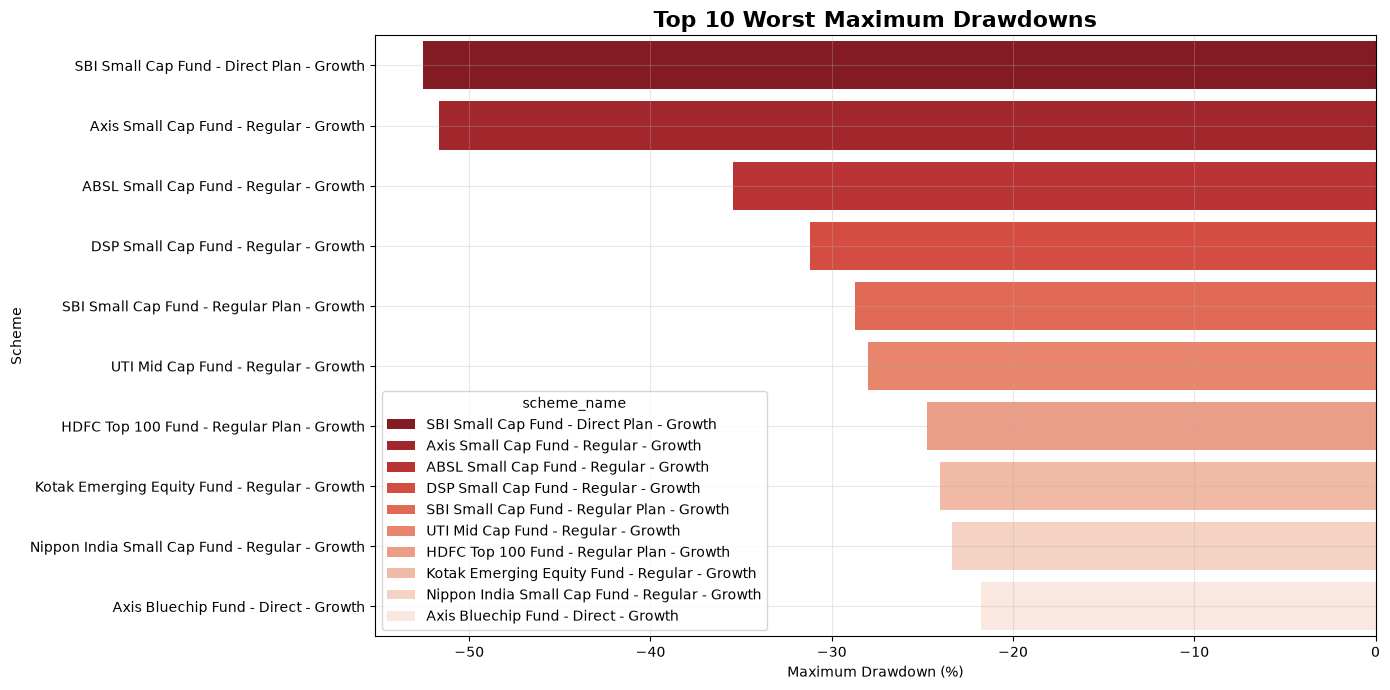

In [60]:
worst10 = mdd.head(10)

plt.figure(figsize=(14,7))

sns.barplot(
    data=worst10,
    x="Maximum_Drawdown",
    y="scheme_name",
    hue="scheme_name",
    palette="Reds_r",
    legend= True
)

plt.title(
    "Top 10 Worst Maximum Drawdowns",
    fontsize=16,
    fontweight="bold"
)

plt.xlabel("Maximum Drawdown (%)")

plt.ylabel("Scheme")

plt.grid(alpha=0.3)

plt.tight_layout()

plt.savefig(
    os.path.join(
        chart_path,
        "task6_max_drawdown.png"
    ),
    dpi=300
)

plt.show()

# Task 7: Mutual Fund Scorecard

## Objective

Develop a composite score (0–100) to rank mutual funds using multiple performance metrics.

### Score Components

- 30% → 3-Year CAGR Rank
- 25% → Sharpe Ratio Rank
- 20% → Alpha Rank
- 15% → Expense Ratio Rank (Lower is Better)
- 10% → Maximum Drawdown Rank (Lower Drawdown is Better)

## Purpose

- Provide a single performance score.
- Rank funds objectively.
- Simplify investment decision-making.

In this task we required column of fund master

In [61]:
expense = fund_master[
    ["amfi_code", "scheme_name", "expense_ratio_pct"]
]


 Merge All Metrics

In [62]:
scorecard = (
    expense
    .merge(
        cagr_table[
            ["amfi_code", "CAGR_3Y"]
        ],
        on="amfi_code"
    )
    .merge(
        sharpe[
            ["amfi_code", "Sharpe_Ratio"]
        ],
        on="amfi_code"
    )
    .merge(
        alpha_beta[
            ["amfi_code", "Alpha"]
        ],
        on="amfi_code"
    )
    .merge(
        mdd[
            ["amfi_code", "Maximum_Drawdown"]
        ],
        on="amfi_code"
    )
)


 Ranking

In [63]:
scorecard["Return_Rank"] = scorecard["CAGR_3Y"].rank(
    ascending=False
)

scorecard["Sharpe_Rank"] = scorecard["Sharpe_Ratio"].rank(
    ascending=False
)

scorecard["Alpha_Rank"] = scorecard["Alpha"].rank(
    ascending=False
)

scorecard["Expense_Rank"] = scorecard["expense_ratio_pct"].rank(
    ascending=True
)

scorecard["Drawdown_Rank"] = scorecard["Maximum_Drawdown"].rank(
    ascending=True
)


 Normalize Rank


In [64]:
n = len(scorecard)

for col in [
    "Return_Rank",
    "Sharpe_Rank",
    "Alpha_Rank",
    "Expense_Rank",
    "Drawdown_Rank"
]:
    scorecard[col] = (
        (n - scorecard[col])
        /
        (n - 1)
    ) * 100


 Composite Score

In [65]:
scorecard["Fund_Score"] = (

      scorecard["Return_Rank"]*0.30

    + scorecard["Sharpe_Rank"]*0.25

    + scorecard["Alpha_Rank"]*0.20

    + scorecard["Expense_Rank"]*0.15

    + scorecard["Drawdown_Rank"]*0.10

)

 Final Ranking

In [66]:
scorecard = scorecard.sort_values(
    "Fund_Score",
    ascending=False
)

scorecard["Overall_Rank"] = range(
    1,
    len(scorecard)+1
)

In [67]:
# ----------------------------------------------------------
# Save CSV
# ----------------------------------------------------------

scorecard.to_csv(
    os.path.join(
        processed_path,
        "fund_scorecard.csv"
    ),
    index=False
)

display(scorecard.sample(5))

,amfi_code,scheme_name,expense_ratio_pct,CAGR_3Y,Sharpe_Ratio,Alpha,Maximum_Drawdown,Return_Rank,Sharpe_Rank,Alpha_Rank,Expense_Rank,Drawdown_Rank,Fund_Score,Overall_Rank
38,149323,DSP Midcap Fund - Regular - Growth,1.61,26.869991,1.132122,0.265986,-17.248106,74.358974,87.179487,82.051282,5.128205,53.846154,66.666667,12
9,100025,HDFC Short Term Debt Fund - Regular - Growth,0.56,3.916390,-0.567095,0.042818,-4.308264,15.384615,2.564103,5.128205,97.435897,7.692308,21.666667,37
29,101207,ABSL Small Cap Fund - Regular - Growth,1.53,-4.152381,0.162661,0.108971,-35.446916,2.564103,30.769231,33.333333,29.487179,94.871795,29.038462,32
34,148567,Mirae Asset Large Cap Fund - Regular - Growth,1.46,34.000916,1.448291,0.269838,-11.265729,97.435897,100.000000,84.615385,43.589744,17.948718,79.487179,4
11,120504,ICICI Pru Bluechip Fund - Direct - Growth,0.80,32.487429,1.026524,0.211948,-12.588276,94.871795,76.923077,69.230769,71.794872,28.205128,75.128205,6


Visualization

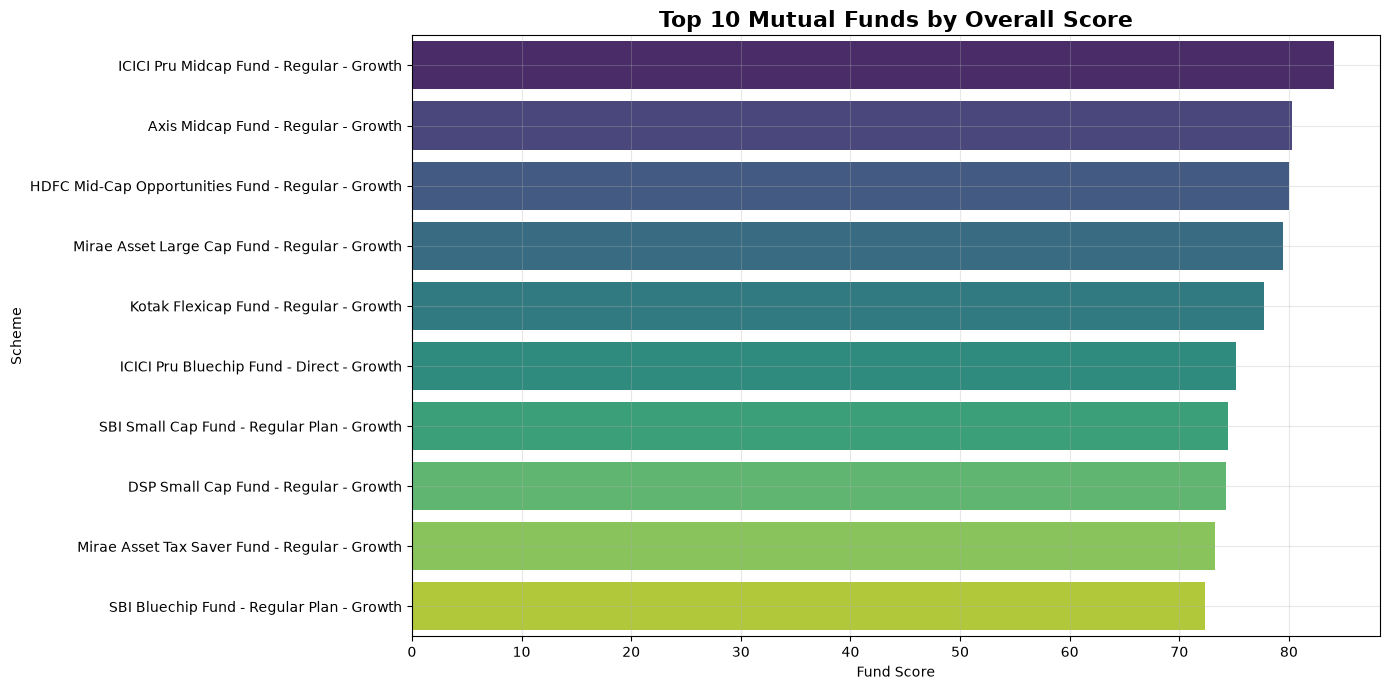

In [68]:
top10 = scorecard.head(10)

plt.figure(figsize=(14,7))

sns.barplot(

    data=top10,

    x="Fund_Score",

    y="scheme_name",

    hue="scheme_name",

    palette="viridis",

    legend=False

)

plt.title(

    "Top 10 Mutual Funds by Overall Score",

    fontsize=16,

    fontweight="bold"

)

plt.xlabel("Fund Score")

plt.ylabel("Scheme")

plt.grid(alpha=.3)

plt.tight_layout()

plt.savefig(

    os.path.join(

        chart_path,

        "task7_fund_scorecard.png"

    ),

    dpi=300

)

plt.show()

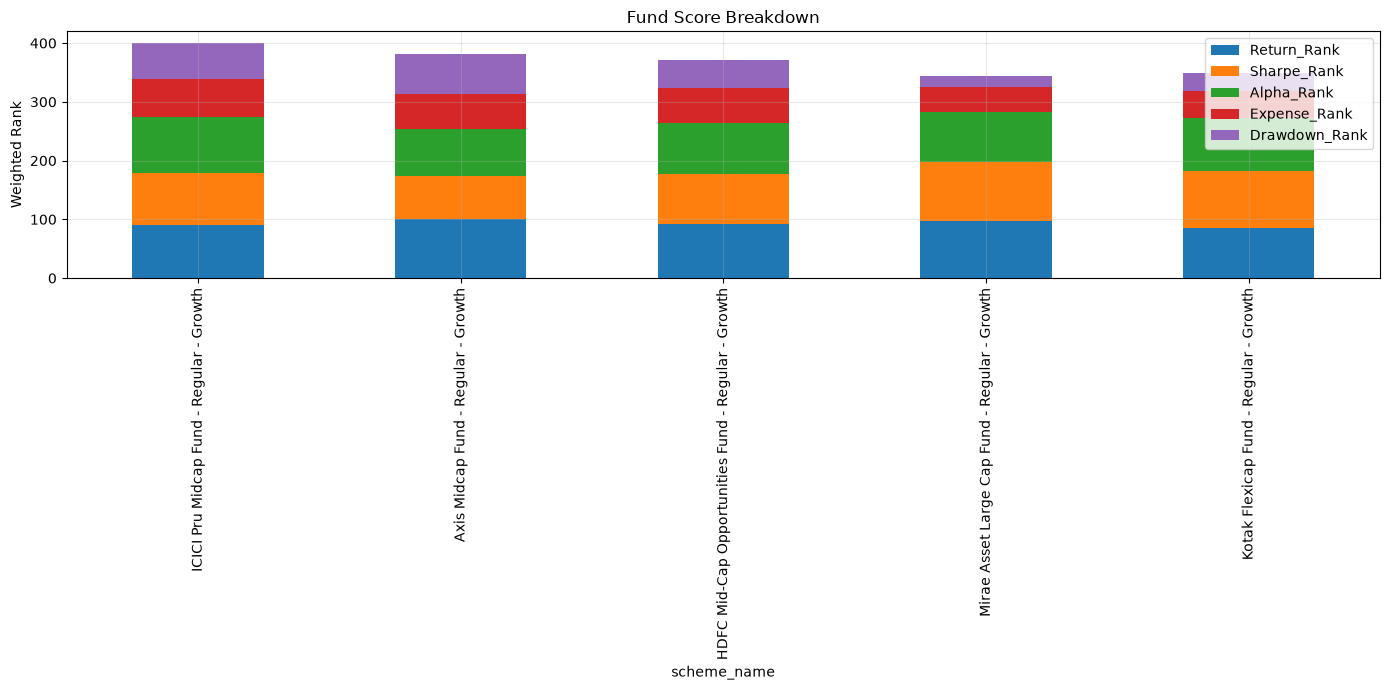

In [69]:
top5 = scorecard.head(5)

plot = top5[
    [
        "scheme_name",
        "Return_Rank",
        "Sharpe_Rank",
        "Alpha_Rank",
        "Expense_Rank",
        "Drawdown_Rank"
    ]
]

plot = plot.set_index("scheme_name")

plot.plot(
    kind="bar",
    stacked=True,
    figsize=(14,7)
)

plt.title("Fund Score Breakdown")

plt.ylabel("Weighted Rank")

plt.grid(alpha=.3)


plt.tight_layout()

plt.savefig(

    os.path.join(

        chart_path,

        "task7_score_breakdown.png"

    ),

    dpi=300

)

plt.show()

# Task 8: Benchmark Comparison

## Objective

Compare the top 5 mutual funds against the NIFTY50 and NIFTY100 indices over the last 3 years.

### Metrics

- Daily NAV Comparison
- Benchmark Comparison
- Tracking Error

### Formula

Tracking Error = Std(Fund Return − Benchmark Return) × √252

## Purpose

- Evaluate benchmark tracking.
- Compare active fund performance.
- Measure deviation from benchmark returns.

In [70]:
# ----------------------------------------------------------
# Top 5 Funds from Scorecard
# ----------------------------------------------------------

top5_codes = scorecard.head(5)["amfi_code"].tolist()

top5_names = (
    scorecard.head(5)
    .set_index("amfi_code")["scheme_name"]
    .to_dict()
)

In [71]:
top5_names

{120505: 'ICICI Pru Midcap Fund - Regular - Growth',
 119094: 'Axis Midcap Fund - Regular - Growth',
 100033: 'HDFC Mid-Cap Opportunities Fund - Regular - Growth',
 148567: 'Mirae Asset Large Cap Fund - Regular - Growth',
 120843: 'Kotak Flexicap Fund - Regular - Growth'}

 Fund NAV Data

In [72]:

fund_nav = nav.copy()

fund_nav["date"] = pd.to_datetime(fund_nav["date"])

last_date = fund_nav["date"].max()

start_date = last_date - pd.DateOffset(years=3)

fund_nav = fund_nav[
    (fund_nav["date"] >= start_date)
    &
    (fund_nav["amfi_code"].isin(top5_codes))
]

Benchmark Data



In [73]:

benchmark = benchmark_df.copy()

benchmark["date"] = pd.to_datetime(
    benchmark["date"]
)

benchmark = benchmark[
    benchmark["date"] >= start_date
]

Normalize NAV / Index


In [74]:
fund_plot = []

for code in top5_codes:

    temp = fund_nav[
        fund_nav["amfi_code"] == code
    ].copy()

    temp = temp.sort_values("date")

    temp["Normalized"] = (
        temp["nav"] /
        temp["nav"].iloc[0]
    ) * 100

    temp["Label"] = top5_names[code]

    fund_plot.append(temp)

fund_plot = pd.concat(fund_plot)

benchmark_plot = []

for idx in ["NIFTY50", "NIFTY100"]:

    temp = benchmark[
        benchmark["index_name"] == idx
    ].copy()

    temp = temp.sort_values("date")

    temp["Normalized"] = (
        temp["close_value"] /
        temp["close_value"].iloc[0]
    ) * 100

    temp["Label"] = idx

    benchmark_plot.append(temp)

benchmark_plot = pd.concat(benchmark_plot)

In [75]:
fund_plot.head(5)

,amfi_code,date,nav,Normalized,Label
14165,120505,2023-05-29,207.0322,100.000000,ICICI Pru Midcap Fund - Regular - Growth
14166,120505,2023-05-30,208.2608,100.593434,ICICI Pru Midcap Fund - Regular - Growth
14167,120505,2023-05-31,209.7025,101.289799,ICICI Pru Midcap Fund - Regular - Growth
14168,120505,2023-06-01,208.7148,100.812724,ICICI Pru Midcap Fund - Regular - Growth
14169,120505,2023-06-02,214.1365,103.431495,ICICI Pru Midcap Fund - Regular - Growth


In [76]:
import plotly.graph_objects as go

fig = go.Figure()

# ----------------------------------------------------------
# Mutual Funds
# ----------------------------------------------------------

for name in fund_plot["Label"].unique():

    temp = fund_plot[
        fund_plot["Label"] == name
    ]

    fig.add_trace(

        go.Scatter(

            x=temp["date"],

            y=temp["Normalized"],

            mode="lines",

            name=name

        )

    )

# ----------------------------------------------------------
# Benchmarks
# ----------------------------------------------------------

for idx in benchmark_plot["Label"].unique():

    temp = benchmark_plot[
        benchmark_plot["Label"] == idx
    ]

    fig.add_trace(

        go.Scatter(

            x=temp["date"],

            y=temp["Normalized"],

            mode="lines",

            line=dict(width=4, dash="dash"),

            name=idx

        )

    )

fig.update_layout(

    title="Top 5 Mutual Funds vs NIFTY50 & NIFTY100",

    title_x=0.5,

    xaxis_title="Date",

    yaxis_title="Normalized Value (Base = 100)",

    hovermode="x unified",

    template="plotly_white",

    height=700

)

fig.show()

fig.write_image(

    os.path.join(

        chart_path,

        "task8_benchmark_comparison.png"

    ),

    width=1800,

    height=900,

    scale=2

)

Tracking Error


In [77]:

benchmark_returns = benchmark[
    benchmark["index_name"] == "NIFTY100"
][
    ["date", "close_value"]
].copy()

benchmark_returns["benchmark_return"] = (
    benchmark_returns["close_value"]
    .pct_change()
)

tracking = []

for code in top5_codes:

    fund = daily_returns_df[
        daily_returns_df["amfi_code"] == code
    ][
        ["date", "daily_return"]
    ].copy()

    merged = pd.merge(

        fund,

        benchmark_returns[
            ["date", "benchmark_return"]
        ],

        on="date",

        how="inner"

    ).dropna()

    te = (
        np.std(

            merged["daily_return"] -
            merged["benchmark_return"]

        )

        * np.sqrt(252)

    )

    tracking.append([

        top5_names[code],

        te

    ])

tracking_df = pd.DataFrame(

    tracking,

    columns=[

        "Scheme",

        "Tracking_Error"

    ]

)

tracking_df = tracking_df.sort_values(
    "Tracking_Error"
)

tracking_df.to_csv(

    os.path.join(

        processed_path,

        "benchmark_comparison.csv"

    ),

    index=False

)

tracking_df

,Scheme,Tracking_Error
3,Mirae Asset Large Cap Fund - Regular - Growth,0.187854
4,Kotak Flexicap Fund - Regular - Growth,0.206408
2,HDFC Mid-Cap Opportunities Fund - Regular - Gr...,0.224833
0,ICICI Pru Midcap Fund - Regular - Growth,0.232513
1,Axis Midcap Fund - Regular - Growth,0.239621


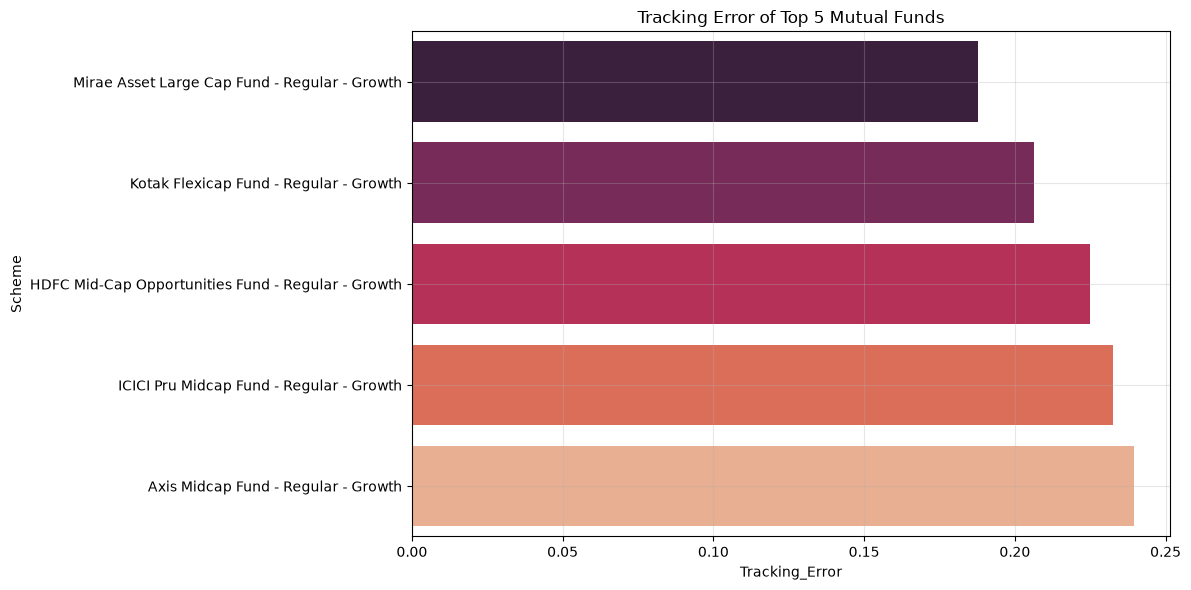

In [78]:
plt.figure(figsize=(12,6))

sns.barplot(

    data=tracking_df,

    x="Tracking_Error",

    y="Scheme",

    hue="Scheme",

    palette="rocket",

    legend=False

)

plt.title("Tracking Error of Top 5 Mutual Funds")

plt.grid(alpha=.3)

plt.tight_layout()

plt.savefig(

    os.path.join(

        chart_path,

        "task8_tracking_error.png"

    ),

    dpi=300

)

plt.show()